In [2]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tqdm.auto as tqdm

/Users/toanly/Main/Class/Deep Learning/CS-5137-Deep-Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
batch_size = 64

In [6]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
test_size = len(test_dataset)

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train set size: {len(train_dataset)}')
print(f'Validation set size: {len(val_dataset)}')
print(f'Test set size: {len(test_dataset)}')

Train set size: 48000
Validation set size: 12000
Test set size: 10000


# Models

In [7]:
def get_activation(act_str):
    if act_str == 'relu':
        return nn.ReLU()
    elif act_str == 'tanh':
        return nn.Tanh()
    elif act_str == 'sigmoid':
        return nn.Sigmoid()
    elif act_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif act_str == 'softmax':
        return nn.Softmax(dim=1)
    elif act_str == 'gelu':
        return nn.GELU()
    else:
        raise ValueError(f"Unsupported activation function: {act_str}")

## DNN

In [8]:
class DNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_layers: list = [256, 128],
        output_dim: int = 10,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        super(DNN, self).__init__()
        self.activation = get_activation(activation)

        layers = []

        prev_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten input image
        return self.model(x)

## ConvNet

In [9]:
class CNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        input_channels: int = 1,
        conv_layers: list = [32, 64],
        fc_layers: list = [128],
        output_dim: int = 10,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        super(CNN, self).__init__()
        self.activation = get_activation(activation)

        layers = []
        prev_channels = input_channels
        for out_channels in conv_layers:
            layers.append(nn.Conv2d(prev_channels, out_channels, kernel_size, stride, padding))
            if batch_norm:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(self.activation)
            layers.append(nn.MaxPool2d(2, 2))
            if dropout > 0:
                layers.append(nn.Dropout2d(dropout))
            prev_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)

        # Compute the size of the feature map after the convolutional layers
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 28, 28)
            conv_output = self.feature_extractor(dummy_input)
            conv_output_size = conv_output.view(1, -1).size(1)

        fc_layers_full = [conv_output_size] + fc_layers + [output_dim]
        fc_layers_seq = []
        for i in range(len(fc_layers_full) - 1):
            fc_layers_seq.append(nn.Linear(fc_layers_full[i], fc_layers_full[i+1]))
            if i < len(fc_layers_full) - 2:
                if batch_norm:
                    fc_layers_seq.append(nn.BatchNorm1d(fc_layers_full[i+1]))
                fc_layers_seq.append(self.activation)
                if dropout > 0:
                    fc_layers_seq.append(nn.Dropout(dropout))

        self.fc = nn.Sequential(*fc_layers_seq)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

## ResNet

In [10]:
class ResNet(nn.Module):
    def __init__(
        self,
        output_dim: int = 10,
        pretrained: bool = False,
    ):
        super(ResNet, self).__init__()
        self.resnet = models.resnet18(pretrained=pretrained)
        pass


## DenseNet

## Training

In [11]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        test_loader,
        device=None,
        lr=0.001,
        early_stopping=True,
        early_stopping_patience=10,
    ):
        self.device = device or (torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        # print(f'Using device: {self.device}')
        self.model = model.to(self.device)
        # print(self.model)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Early stopping
        self.early_stopping = early_stopping
        if early_stopping:
            self.early_stopping_patience = early_stopping_patience
            self.best_val_loss = float('inf')
            self.epochs_no_improve = 0
            self.best_weights = None

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_train, y_train in tqdm.tqdm(self.train_loader, desc="Training", leave=False):
        # for X_train, y_train in self.train_loader:
            X_train, y_train = X_train.to(self.device), y_train.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(X_train)
            loss = self.criterion(outputs, y_train)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * X_train.size(0)
            _, preds = torch.max(outputs.data, 1)
            total += y_train.size(0)
            correct += (preds == y_train).sum().item()

        epoch_loss = running_loss / len(self.train_loader.dataset)
        return epoch_loss, correct / total

    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_val, y_val in tqdm.tqdm(self.val_loader, desc="Validation", leave=False):
            # for X_val, y_val in self.val_loader:
                X_val, y_val = X_val.to(self.device), y_val.to(self.device)

                outputs = self.model(X_val)
                loss = self.criterion(outputs, y_val)

                running_loss += loss.item() * X_val.size(0)
                _, preds = torch.max(outputs.data, 1)
                total += y_val.size(0)
                correct += (preds == y_val).sum().item()

        epoch_loss = running_loss / len(self.val_loader.dataset)
        return epoch_loss, correct / total

    def test(self):
        self.model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_test, y_test in tqdm.tqdm(self.test_loader, desc='Testing', leave=False):
                X_test, y_test = X_test.to(self.device), y_test.to(self.device)
                outputs = self.model(X_test)
                _, preds = torch.max(outputs, 1)
                correct += (preds == y_test).sum().item()
                total += y_test.size(0)

        return correct / total

    def fit(self, epochs=100, verbose=True, saved_model_path=None):
        for epoch in range(epochs):
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if verbose and (epoch + 1) % (epochs // 10) == 0:
                print(f'Epoch [{epoch+1}/{epochs}]'
                      f' Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}'
                      f' | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

            best_weights = None
            if self.early_stopping:
                if val_loss < self.best_val_loss:
                    self.best_val_loss = val_loss
                    self.epochs_no_improve = 0
                    best_weights = self.model.state_dict()
                else:
                    self.epochs_no_improve += 1
                    if self.epochs_no_improve >= self.early_stopping_patience:
                        print("Early stopping at epoch", epoch+1)
                        if best_weights is not None:
                            self.model.load_state_dict(best_weights)
                        break
        if saved_model_path:
            torch.save(self.model.state_dict(), saved_model_path)

        return self.history

In [12]:
lr = 0.001
input_dim = 28*28
input_channels = 1
epochs = 10

In [13]:
models = {
    'DNN': DNN(input_dim=input_dim, hidden_layers=[256, 128], dropout=0.0, batch_norm=True, activation='relu'),
    'CNN': CNN(input_channels=input_channels, conv_layers=[32, 64], fc_layers=[128], dropout=0.0, batch_norm=True, activation='relu'),
    # 'ResNet': ResNet(pretrained=False),
}

### Test if models' implementations are correct

In [14]:
sample_inputs, sample_labels = next(iter(train_loader))

models['DNN'] = models['DNN'].to(device)
models['CNN'] = models['CNN'].to(device)
y1 = models['DNN'](sample_inputs.to(device))
y2 = models['CNN'](sample_inputs.to(device))
y1.shape, y2.shape

(torch.Size([64, 10]), torch.Size([64, 10]))

In [15]:
saved_path = '../weights/'
if not os.path.exists(saved_path):
    os.makedirs(saved_path)

for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    trainer = Trainer(model, train_loader, val_loader, test_loader, device=device, lr=lr)
    history = trainer.fit(epochs=epochs, saved_model_path=os.path.join(saved_path, f'{model_name}_best.pth'))
    test_acc = trainer.test()
    print(f'{model_name} Test Accuracy: {test_acc:.4f}')


Training DNN...


Epoch [1/10] Train Loss: 0.2310, Train Acc: 0.9361 | Val Loss: 0.1069, Val Acc: 0.9683


Epoch [2/10] Train Loss: 0.0901, Train Acc: 0.9729 | Val Loss: 0.0942, Val Acc: 0.9698


Epoch [3/10] Train Loss: 0.0633, Train Acc: 0.9801 | Val Loss: 0.0837, Val Acc: 0.9742


Epoch [4/10] Train Loss: 0.0477, Train Acc: 0.9848 | Val Loss: 0.0742, Val Acc: 0.9757


...

Epoch [7/10] Train Loss: 0.0083, Train Acc: 0.9975 | Val Loss: 0.0341, Val Acc: 0.9892


Epoch [8/10] Train Loss: 0.0079, Train Acc: 0.9974 | Val Loss: 0.0371, Val Acc: 0.9892


Epoch [9/10] Train Loss: 0.0081, Train Acc: 0.9973 | Val Loss: 0.0323, Val Acc: 0.9911


Epoch [10/10] Train Loss: 0.0063, Train Acc: 0.9980 | Val Loss: 0.0307, Val Acc: 0.9916


CNN Test Accuracy: 0.9908


## Inference

In [19]:
def inference(model, dataloader, n_images, n_cols=4):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:n_images].to(device), labels[:n_images].to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    n_rows = (n_images + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    for i in range(n_images):
        plt.subplot(n_rows, n_cols, i + 1)
        img = images[i].cpu().numpy().squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f'Ground Truth: {labels[i].item()}, Prediction: {preds[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Inference with DNN...


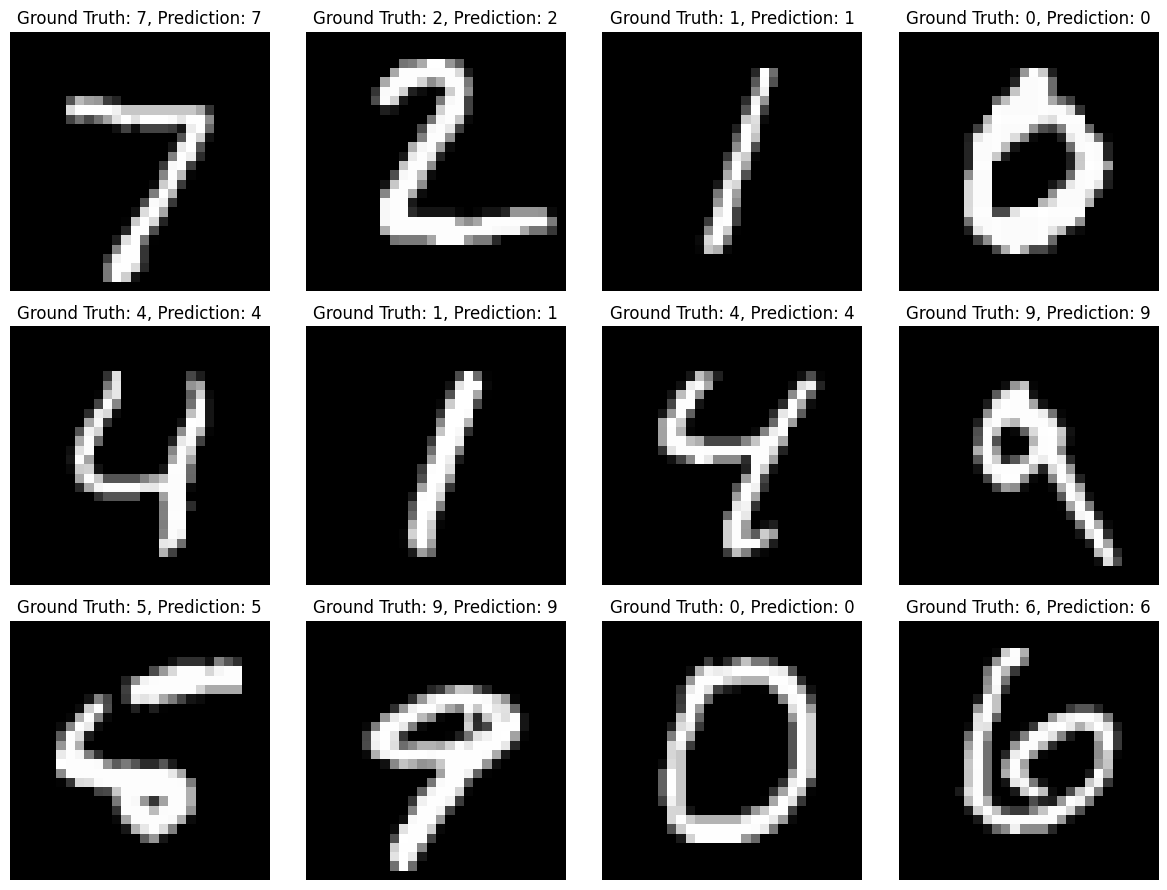


Inference with CNN...


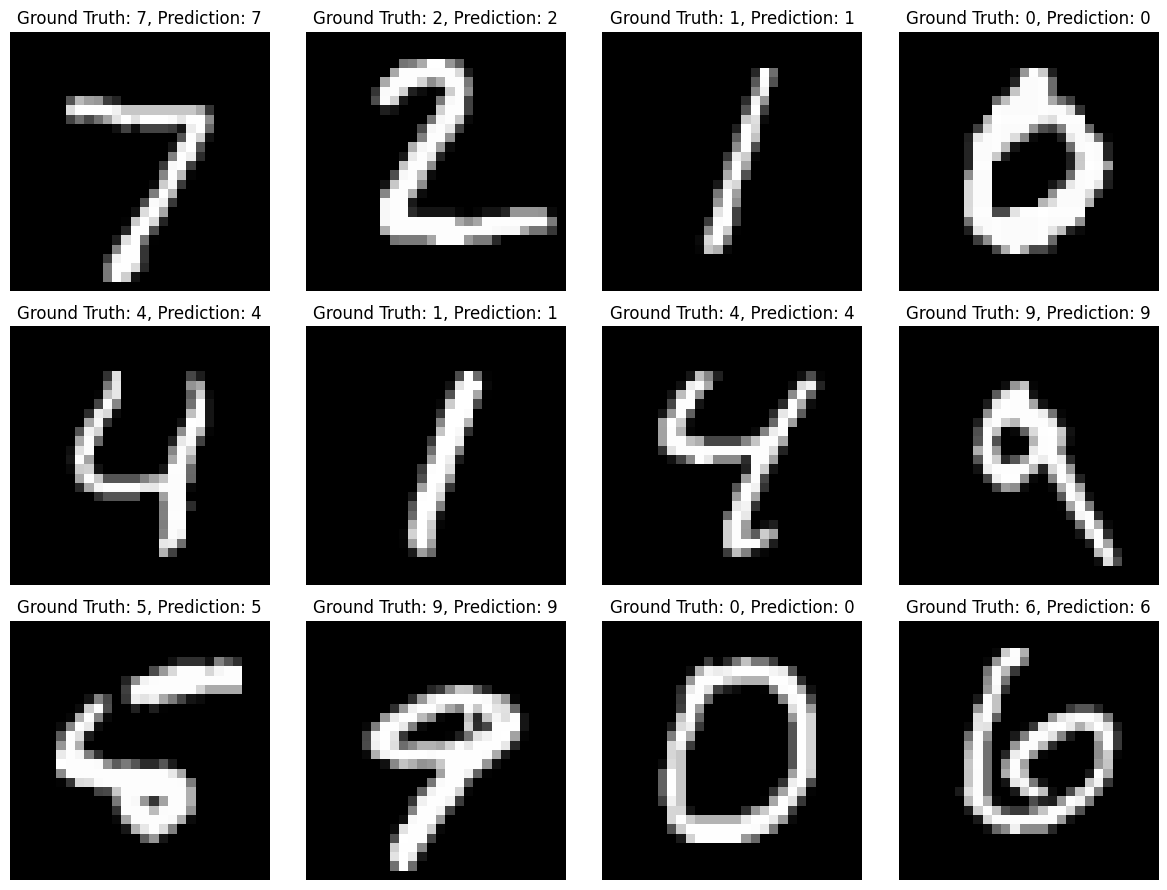

In [20]:
for model_name, model in models.items():
    print(f'\nInference with {model_name}...')
    model.load_state_dict(torch.load(os.path.join(saved_path, f'{model_name}_best.pth')))
    inference(model, test_loader, n_images=12)